In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
import cvxpy as cvx
import riskfolio as rf

import statsmodels.api as sm

import scipy.stats as st
from scipy.linalg import expm, logm, sqrtm

import datetime as dt
from arch import arch_model

from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

In [4]:
# 1. Generate some sample data (e.g., simulated returns)
np.random.seed(42)
# Simulate a series with GARCH-like volatility
returns = np.random.normal(0, 1, 500)
# Introduce some volatility clustering for demonstration
for i in range(1, len(returns)):
    if i % 50 == 0:
        returns[i:i+20] *= 2 # Increase volatility for a period

returns_series = pd.Series(returns, name="returns")

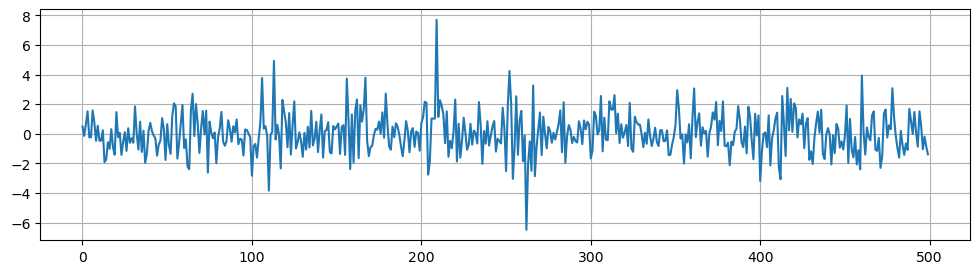

In [7]:
_ = returns_series.plot(figsize=(12,3), grid=True)

In [8]:
# 2. Fit a GARCH(1,1) model
# mean='Zero' assumes a zero mean for the returns
# vol='Garch' specifies the GARCH model
# p=1, q=1 specifies GARCH(1,1)
# dist='Normal' assumes normally distributed errors (can be changed to 't' for Student's t-distribution)
model = arch_model(returns_series, mean='Zero', vol='Garch', p=1, q=1, dist='Normal')
res = model.fit(disp='off') # disp='off' suppresses iteration details

# 3. Print the model summary
print(res.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.002
Vol Model:                      GARCH   Log-Likelihood:               -853.417
Distribution:                  Normal   AIC:                           1712.83
Method:            Maximum Likelihood   BIC:                           1725.48
                                        No. Observations:                  500
Date:                Sat, Nov 15 2025   Df Residuals:                      500
Time:                        17:32:11   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.1948  6.714e-02      2.901  3.720e-03 [6.317e-0

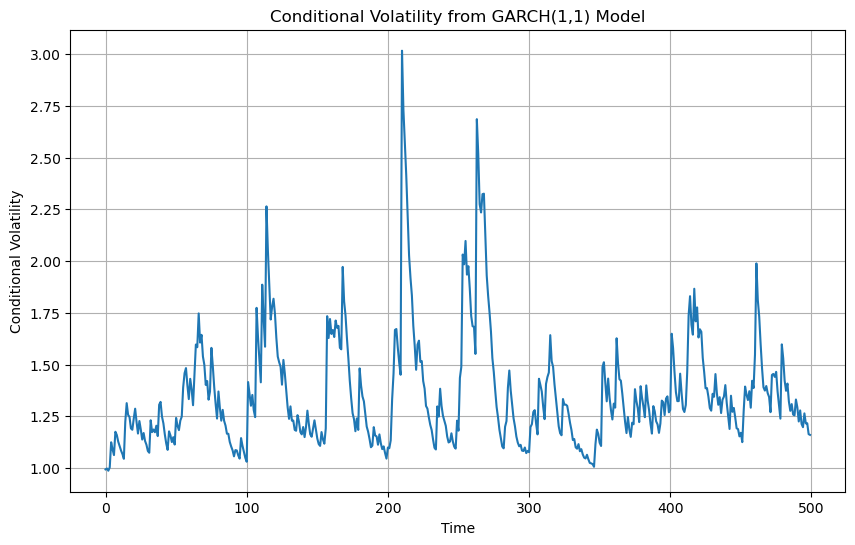


Forecasted Conditional Volatility (5 steps ahead):
 h.1    1.478898
h.2    1.530056
h.3    1.576248
h.4    1.617954
h.5    1.655610
Name: 499, dtype: float64


In [9]:
# 4. Plot the conditional variance
plt.figure(figsize=(10, 6))
plt.plot(res.conditional_volatility)
plt.title('Conditional Volatility from GARCH(1,1) Model')
plt.xlabel('Time')
plt.ylabel('Conditional Volatility')
plt.grid(True)
plt.show()

# 5. Forecast future volatility (example for 5 steps ahead)
forecasts = res.forecast(horizon=5)
print("\nForecasted Conditional Volatility (5 steps ahead):\n", forecasts.variance.iloc[-1])